In [4]:
import numpy as np
import pandas as Pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
ratings = Pd.read_csv('u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Load movies data
movies = Pd.read_csv('u.item', sep='|', encoding='latin-1',
                     names=['movie_id', 'title', 'release_date', 'video_release_date',
                            'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                            'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama',
                            'Fantasy', 'Film_Noir', 'Horror', 'Musical', 'Mystery',
                            'Romance', 'Sci_Fi', 'Thriller', 'War', 'Western'])

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("\nRatings sample:")
print(ratings.head())
print("\nMovies sample:")
print(movies.head())

Ratings shape: (100000, 4)
Movies shape: (1682, 24)

Ratings sample:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

Movies sample:
   movie_id              title release_date  video_release_date  \
0         1   Toy Story (1995)  01-Jan-1995                 NaN   
1         2   GoldenEye (1995)  01-Jan-1995                 NaN   
2         3  Four Rooms (1995)  01-Jan-1995                 NaN   
3         4  Get Shorty (1995)  01-Jan-1995                 NaN   
4         5     Copycat (1995)  01-Jan-1995                 NaN   

                                            imdb_url  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%... 

In [8]:
print("=== RATINGS INFO ===")
print(ratings.info())
print("\nMissing values in ratings:")
print(ratings.isnull().sum())

print("\n=== MOVIES INFO ===")
print(movies.info())
print("\nMissing values in movies:")
print(movies.isnull().sum())

print("\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

=== RATINGS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

Missing values in ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

=== MOVIES INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            1682 non-null   int64  
 1   title               1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   imdb_url            1679 non-null   object 
 5   unknown         

In [9]:
# Drop columns we don't need
movies = movies.drop(columns=['video_release_date', 'imdb_url', 'unknown'])

# Drop timestamp from ratings we don't need it
ratings = ratings.drop(columns=['timestamp'])

# Verify
print("Movies columns after cleaning:")
print(movies.columns.tolist())
print("\nRatings columns after cleaning:")
print(ratings.columns.tolist())

print("\nMovies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

print("\nAny missing values left in movies?")
print(movies.isnull().sum())

Movies columns after cleaning:
['movie_id', 'title', 'release_date', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci_Fi', 'Thriller', 'War', 'Western']

Ratings columns after cleaning:
['user_id', 'movie_id', 'rating']

Movies shape: (1682, 21)
Ratings shape: (100000, 3)

Any missing values left in movies?
movie_id        0
title           0
release_date    1
Action          0
Adventure       0
Animation       0
Childrens       0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film_Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci_Fi          0
Thriller        0
War             0
Western         0
dtype: int64


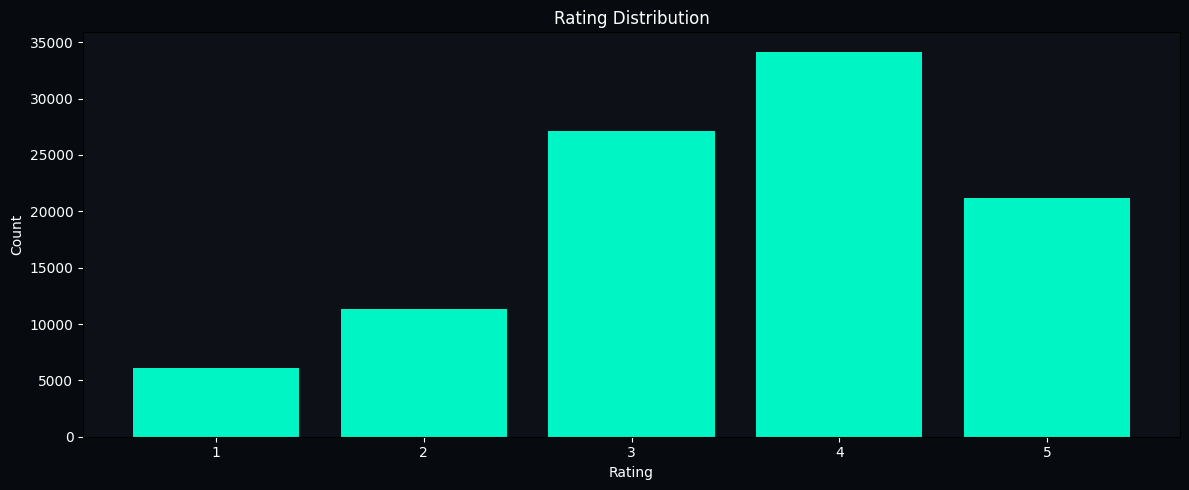

In [10]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#0d1117'
plt.rcParams['figure.facecolor'] = '#070b0f'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# Plot 1 — Rating Distribution
plt.figure()
rating_counts = ratings['rating'].value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values, color='#00f5c4')
plt.title('Rating Distribution', color='white')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()






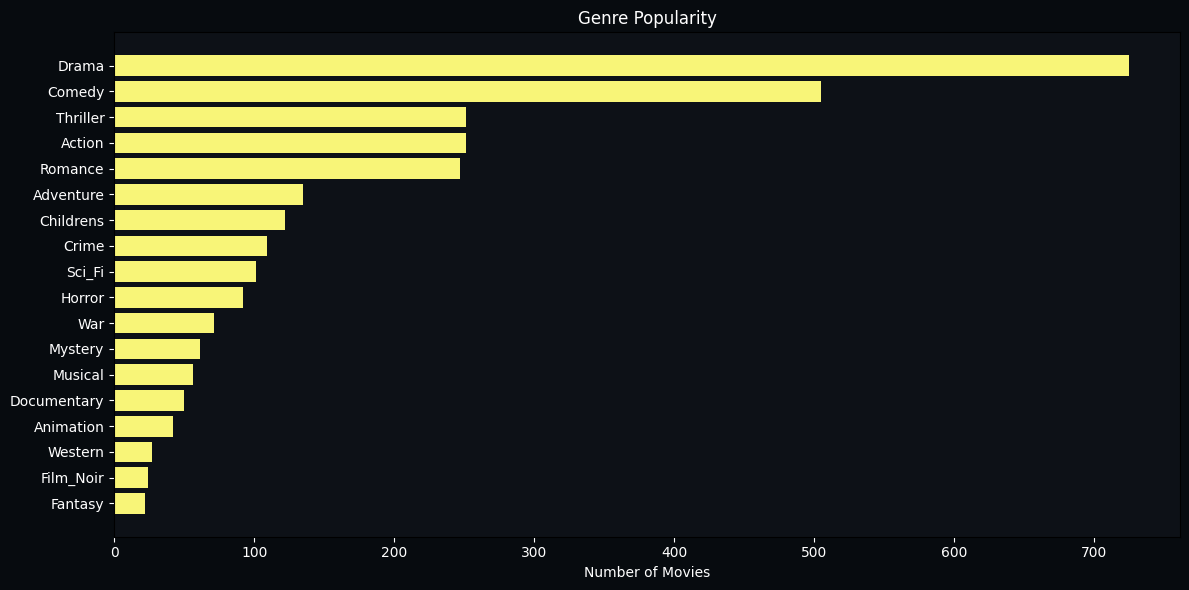

In [12]:
# Plot 2 — Genre Popularity
genre_cols = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir',
              'Horror', 'Musical', 'Mystery', 'Romance', 'Sci_Fi',
              'Thriller', 'War', 'Western']

genre_counts = movies[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(genre_counts.index, genre_counts.values, color='#f8f578')
plt.title('Genre Popularity', color='white')
plt.xlabel('Number of Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

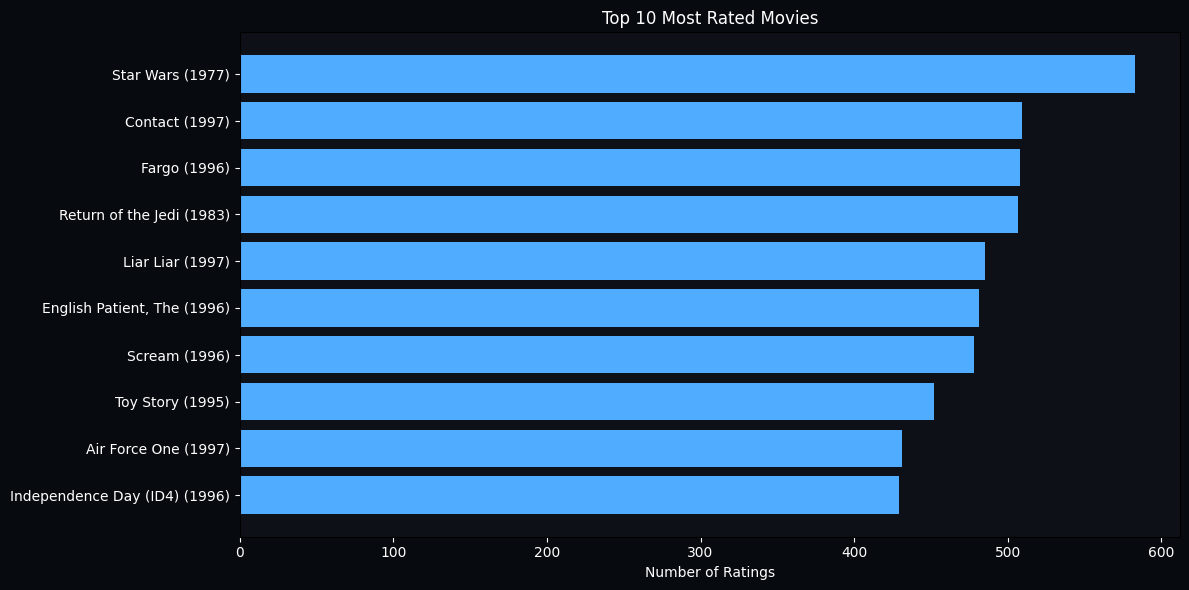

In [11]:
# Plot 3 — Top 10 Most Rated Movies
top_movies = ratings.groupby('movie_id')['rating'].count().sort_values(ascending=False).head(10)
top_movie_titles = movies[movies['movie_id'].isin(top_movies.index)][['movie_id', 'title']]
top_movies_df = top_movies.reset_index().merge(top_movie_titles, on='movie_id')

plt.figure(figsize=(12, 6))
plt.barh(top_movies_df['title'], top_movies_df['rating'], color='#4facfe')
plt.title('Top 10 Most Rated Movies', color='white')
plt.xlabel('Number of Ratings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()